# Smart Lender – Loan Approval Prediction System

## Loan Eligibility Prediction using Machine Learning

### Objective

The objective of this project is to predict whether a customer is eligible for a loan based on applicant details such as income, education, credit history, loan amount, and property area.

This project uses Machine Learning algorithms to assist banks in making faster and more accurate loan approval decisions.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Flask
- Pickle

In [25]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Import train-test split
from sklearn.model_selection import train_test_split

# Import Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Import SMOTE for balancing the dataset
from imblearn.over_sampling import SMOTE

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Import Pickle to save the trained model
import pickle

In [26]:
# ==========================================================
# Step 2: Load the Loan Prediction Dataset
# ==========================================================

# Read the loan prediction dataset
df = pd.read_csv("dataset/loan_prediction.csv")

In [27]:
# ==========================================================
# Step 3: Display the Dataset
# ==========================================================

# Display the first five rows of the dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [28]:
# ==========================================================
# Step 4: Dataset Information
# ==========================================================

# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [29]:
# ==========================================================
# Step 5: Statistical Summary
# ==========================================================

# Display statistical summary of numerical columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [30]:
# ==========================================================
# Step 6: Check Missing Values
# ==========================================================

# Check missing values in each column
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
# ==========================================================
# Step 7: Handle Missing Values
# ==========================================================

# Fill numerical missing values using mean

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean())

df["ApplicantIncome"] = df["ApplicantIncome"].fillna(df["ApplicantIncome"].mean())

df["CoapplicantIncome"] = df["CoapplicantIncome"].fillna(df["CoapplicantIncome"].mean())


# Fill categorical missing values using mode

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [32]:
# ==========================================================
# Step 8: Verify Missing Values
# ==========================================================

# Check whether all missing values are handled

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [33]:
# ==========================================================
# Step 9: Set Plot Style
# ==========================================================

# Set the plotting style

plt.style.use("fivethirtyeight")

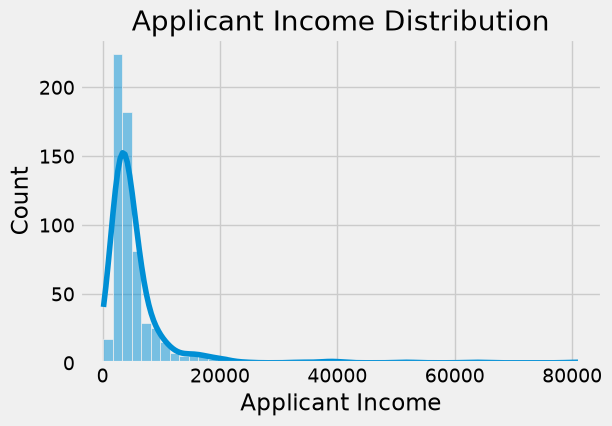

In [35]:
# ==========================================================
# Step 10: Applicant Income Distribution
# ==========================================================

# Display the distribution of applicant income

plt.figure(figsize=(6,4))

sns.histplot(df["ApplicantIncome"], kde=True)

plt.title("Applicant Income Distribution")

plt.xlabel("Applicant Income")

plt.ylabel("Count")

plt.show()

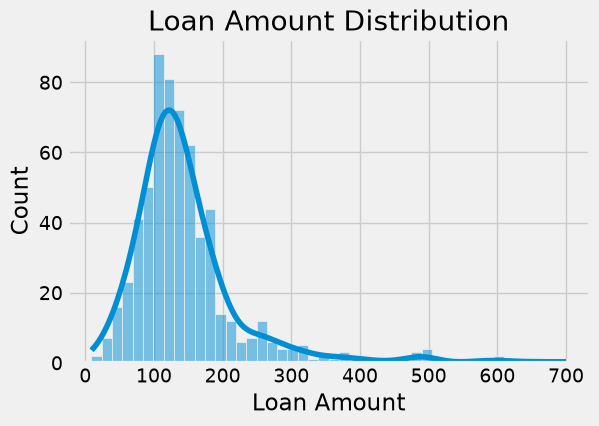

In [36]:
# ==========================================================
# Step 11: Loan Amount Distribution
# ==========================================================

# Display the distribution of loan amount

plt.figure(figsize=(6,4))

sns.histplot(df["LoanAmount"], kde=True)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.ylabel("Count")

plt.show()

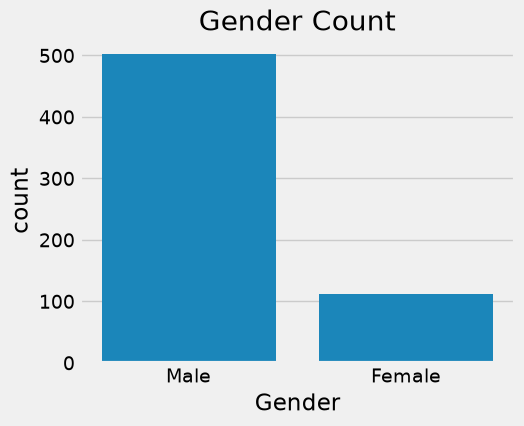

In [37]:
# ==========================================================
# Step 12: Gender Count Plot
# ==========================================================

# Display the number of applicants based on gender

plt.figure(figsize=(5,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Count")

plt.show()

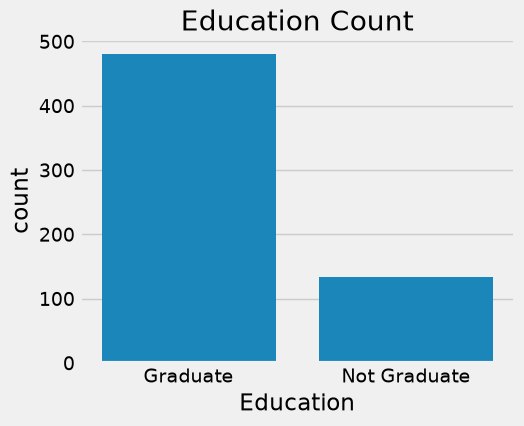

In [38]:
# ==========================================================
# Step 13: Education Count Plot
# ==========================================================

# Display the number of applicants based on education

plt.figure(figsize=(5,4))

sns.countplot(x="Education", data=df)

plt.title("Education Count")

plt.show()

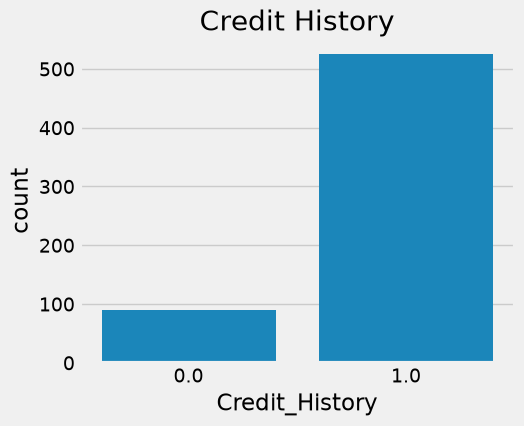

In [39]:
# ==========================================================
# Step 14: Credit History Count Plot
# ==========================================================

# Display the number of applicants based on credit history

plt.figure(figsize=(5,4))

sns.countplot(x="Credit_History", data=df)

plt.title("Credit History")

plt.show()

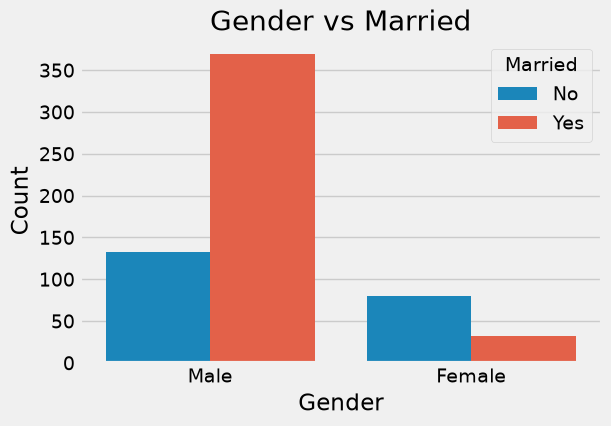

In [40]:
# ==========================================================
# Step 15: Bivariate Analysis
# Gender vs Married
# ==========================================================

# Display the relationship between Gender and Married Status

plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Married", data=df)

plt.title("Gender vs Married")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

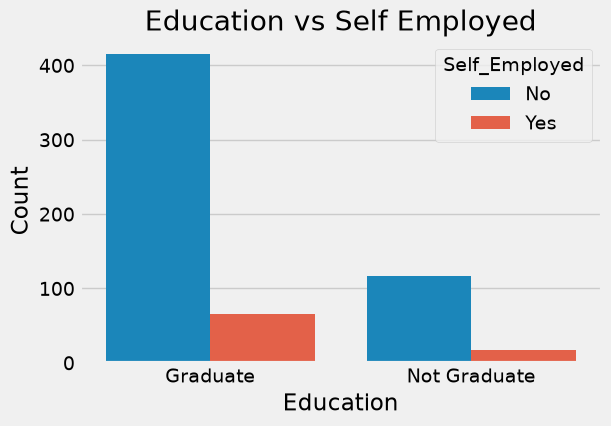

In [41]:
# ==========================================================
# Step 16: Bivariate Analysis
# Education vs Self Employed
# ==========================================================

# Display the relationship between Education and Self Employment

plt.figure(figsize=(6,4))

sns.countplot(x="Education", hue="Self_Employed", data=df)

plt.title("Education vs Self Employed")

plt.xlabel("Education")

plt.ylabel("Count")

plt.show()

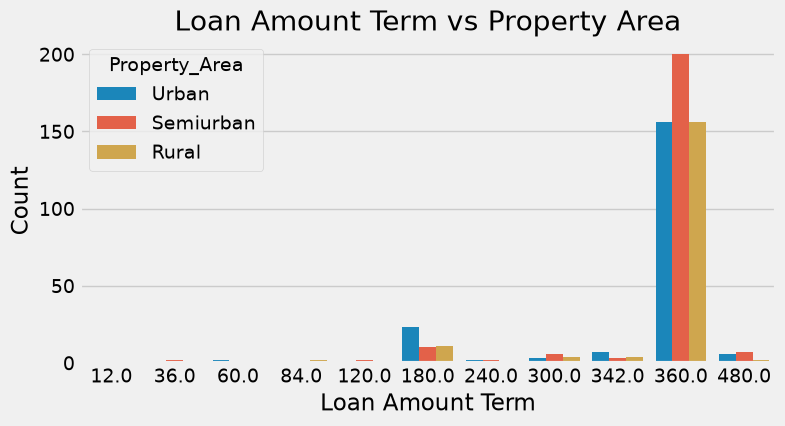

In [43]:
# ==========================================================
# Step 17: Bivariate Analysis
# Loan Amount Term vs Property Area
# ==========================================================

# Display the relationship between Loan Amount Term and Property Area

plt.figure(figsize=(8,4))

sns.countplot(x="Loan_Amount_Term", hue="Property_Area", data=df)

plt.title("Loan Amount Term vs Property Area")

plt.xlabel("Loan Amount Term")

plt.ylabel("Count")

plt.show()

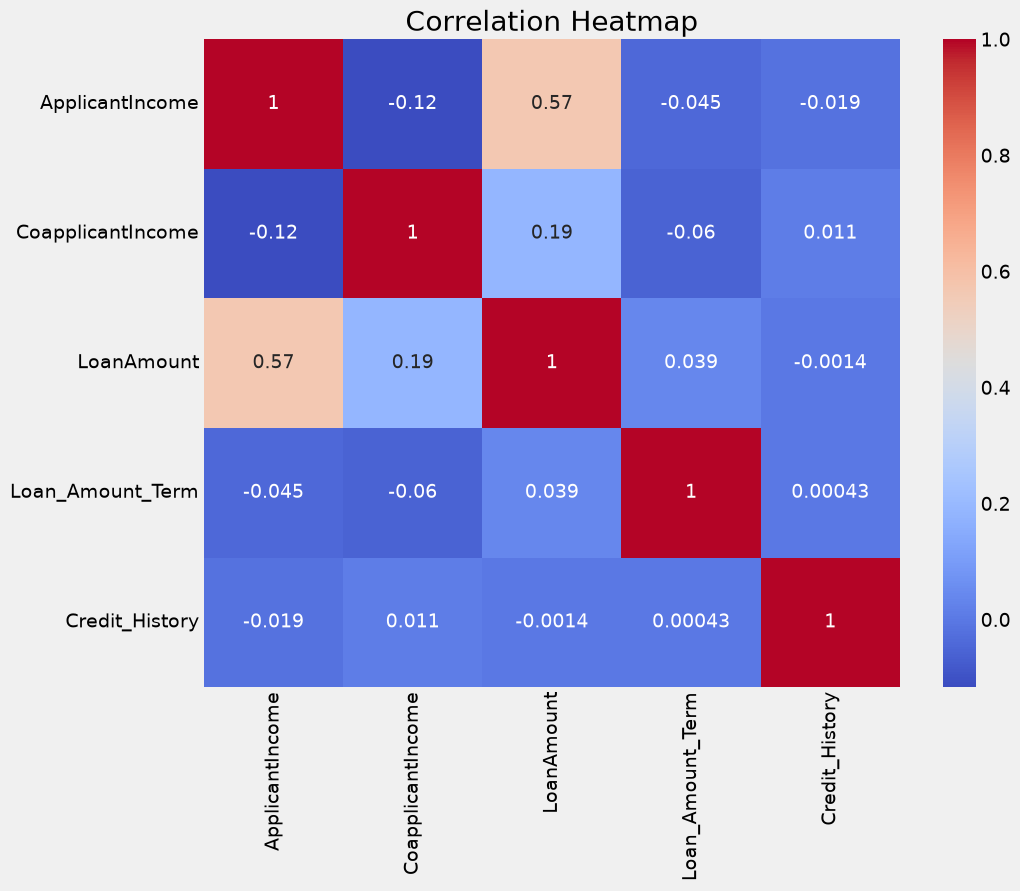

In [44]:
# ==========================================================
# Step 18: Correlation Heatmap
# ==========================================================

# Display correlation between numerical features

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [46]:
# ==========================================================
# Step 19: Label Encoding
# ==========================================================

# Convert categorical values into numerical values

le = LabelEncoder()

columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in columns:
    df[col] = le.fit_transform(df[col])

# Display the updated dataset

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [47]:
# ==========================================================
# Step 20: Separate Features and Target
# ==========================================================

# Separate independent variables (X)
# and dependent variable (y)

X = df.drop(["Loan_ID", "Loan_Status"], axis=1)

y = df["Loan_Status"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (614, 11)
Target Shape : (614,)


In [48]:
# ==========================================================
# Step 21: Balance the Dataset using SMOTE
# ==========================================================

# SMOTE is used to balance the classes in the dataset

smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

print("After Applying SMOTE")

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

After Applying SMOTE
Features Shape : (844, 11)
Target Shape : (844,)


In [49]:
# ==========================================================
# Step 22: Feature Scaling
# ==========================================================

# Standardize the numerical features

scaler = StandardScaler()

X = scaler.fit_transform(X)

# Save the scaler for Flask application

pickle.dump(scaler, open("model/scaler.pkl", "wb"))

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [50]:
# ==========================================================
# Step 23: Split Dataset into Training and Testing Data
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (675, 11)
Testing Data : (169, 11)


In [51]:
# ==========================================================
# Step 24: Create Machine Learning Models
# ==========================================================

models = {

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "K-Nearest Neighbors":
    KNeighborsClassifier(),

    "XGBoost":
    XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss"
    )

}

In [53]:
# ==========================================================
# Step 25: Train Models and Compare Accuracy
# ==========================================================

best_model = None

best_accuracy = 0

print("=" * 60)

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    prediction = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, prediction)

    print("\n", "=" * 60)

    print("Model :", name)

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, prediction))

    print("\nClassification Report")

    print(classification_report(y_test, prediction))

    # Store Best Model
    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model


Model : Decision Tree
Accuracy : 0.7692307692307693

Confusion Matrix
[[72 22]
 [17 58]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        94
           1       0.72      0.77      0.75        75

    accuracy                           0.77       169
   macro avg       0.77      0.77      0.77       169
weighted avg       0.77      0.77      0.77       169


Model : Random Forest
Accuracy : 0.7988165680473372

Confusion Matrix
[[70 24]
 [10 65]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.74      0.80        94
           1       0.73      0.87      0.79        75

    accuracy                           0.80       169
   macro avg       0.80      0.81      0.80       169
weighted avg       0.81      0.80      0.80       169


Model : K-Nearest Neighbors
Accuracy : 0.6923076923076923

Confusion Matrix
[[59 35]
 [17 58]]

Classification Report
 

c:\Users\sunar\Smart-Lender-Loan-Approval-Prediction-System\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:59:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [54]:
# ==========================================================
# Step 26: Best Performing Model
# ==========================================================

print("Best Accuracy :", best_accuracy)

Best Accuracy : 0.8047337278106509


In [55]:
# ==========================================================
# Step 27: Save the Best Model
# ==========================================================

pickle.dump(best_model, open("model/model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [56]:
# ==========================================================
# Step 28: Project Completed Successfully
# ==========================================================

print("Loan Prediction Machine Learning Pipeline Completed Successfully!")

Loan Prediction Machine Learning Pipeline Completed Successfully!
